<a href="https://colab.research.google.com/github/console777/week_Lab05/blob/main/week_lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Exercise 1 (70%): Logistic Regression with Multiple Features

**Your turn.** Use the same ideas as above, but now we have **3 features** per student and **15 samples**. Implement every step yourself in the cells below — replace each `# TODO` with your code.

**Data:** Each student has:
- **hours_studied** (e.g. 1.2, 3.5, …)
- **hours_slept** (e.g. 5, 7, …)
- **attendance** (fraction of classes attended, 0–1)

**Label:** `passed` = 1 if they passed the exam, 0 otherwise.

**Goal:** Build the design matrix \(X\), implement sigmoid, forward pass, loss, gradient, training loop, and prediction. Then report training accuracy.

## Exercise data (15 students)

| hours_studied | hours_slept | attendance | passed |
|---------------|-------------|------------|--------|
| 1.2 | 5 | 0.6 | 0 |
| 1.5 | 6 | 0.7 | 0 |
| 2.0 | 5.5 | 0.5 | 0 |
| 2.2 | 6.5 | 0.8 | 0 |
| 2.8 | 7 | 0.6 | 0 |
| 3.0 | 6 | 0.9 | 1 |
| 3.2 | 7.5 | 0.7 | 1 |
| 3.5 | 7 | 0.85 | 1 |
| 4.0 | 8 | 0.9 | 1 |
| 4.2 | 7 | 0.95 | 1 |
| 4.5 | 8 | 0.8 | 1 |
| 4.8 | 7.5 | 0.9 | 1 |
| 5.0 | 8 | 1.0 | 1 |
| 5.2 | 6.5 | 0.75 | 1 |
| 5.5 | 8 | 0.95 | 1 |

Use the arrays below; your job is to build **X** (with a bias column) and **y**.

In [5]:
import numpy as np

# Raw features (15 samples, 3 features each)
hours_studied = np.array([1.2, 1.5, 2.0, 2.2, 2.8, 3.0, 3.2, 3.5, 4.0, 4.2, 4.5, 4.8, 5.0, 5.2, 5.5], dtype=np.float64)
hours_slept   = np.array([5.0, 6.0, 5.5, 6.5, 7.0, 6.0, 7.5, 7.0, 8.0, 7.0, 8.0, 7.5, 8.0, 6.5, 8.0], dtype=np.float64)
attendance    = np.array([0.6, 0.7, 0.5, 0.8, 0.6, 0.9, 0.7, 0.85, 0.9, 0.95, 0.8, 0.9, 1.0, 0.75, 0.95], dtype=np.float64)

# Labels: 0 = failed, 1 = passed
passed = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float64)

# Build X (15, 3)
X = np.column_stack((hours_studied, hours_slept, attendance))

# Reshape y into column vector (15, 1)
y = passed.reshape(-1, 1)

# Sanity check
print("X shape:", X.shape, "  y shape:", y.shape)

X shape: (15, 3)   y shape: (15, 1)


In [8]:
# TODO: Implement sigmoid(z) = 1 / (1 + exp(-z)). Clip z to avoid overflow (e.g. between -500 and 500).
def sigmoid(z):
  z = np.clip(z, -500, 500)
  return 1.0 /  (1.0 + np.exp(-z))

In [10]:
# TODO: Forward pass. Compute z = X @ w, then p_hat = sigmoid(z). Return p_hat (same shape as z).
def forward(X, w):
    z = X @ w
    p_hat = sigmoid(z)
    return p_hat

In [12]:
# TODO: Binary cross-entropy loss. J = -mean( y*log(p_hat) + (1-y)*log(1-p_hat) ).
# Clip p_hat to [eps, 1-eps] to avoid log(0). Use eps=1e-15.
def binary_cross_entropy(y, p_hat, eps=1e-15):
    p_hat = np.clip(p_hat, eps, 1 - eps)
    return -np.mean(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))

In [13]:
# TODO: Gradient of loss w.r.t. w. grad = (1/n) * X.T @ (p_hat - y). Return shape (4, 1).
def gradient(X, y, p_hat):
    n = X.shape[0]
    return (1/n) * X.T @ (p_hat - y)

### Training loop (gradient descent)
Fill in the TODOs: hyperparameters, weight init, and inside the loop — forward, loss, gradient, weight update.

### Evaluation
Predict class (0/1) for all training samples and compute accuracy.

In [21]:
# TODO: Training loop
# 1. Set learning_rate (e.g. 0.1), epochs (e.g. 1000)
# 2. Initialize w: shape (4, 1), small random (e.g. np.random.randn(4, 1) * 0.1)
# 3. In the loop: forward -> loss -> gradient -> update w
np.random.seed(42)
learning_rate = 0.1   # TODO
epochs = 1000          # TODO

# Adding a bias column to X
X_b = np.column_stack((np.ones(X.shape[0]), X)) # X_b shape: (15, 4)
n_features = X_b.shape[1]
w = np.random.randn(n_features, 1) * 0.1               # TODO: w = np.random.randn(n_features, 1) * 0.1
loss_history = []

for epoch in range(epochs):
    p_hat = forward(X_b, w)   # TODO: forward(X, w)
    loss = binary_cross_entropy(y, p_hat)    # TODO: binary_cross_entropy(y, p_hat)
    loss_history.append(loss)
    grad = gradient(X_b, y, p_hat)    # TODO: gradient(X, y, p_hat)
    w = w - learning_rate * grad       # TODO: w - learning_rate * grad
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 200, Loss: 0.0235
Epoch 400, Loss: 0.0134
Epoch 600, Loss: 0.0095
Epoch 800, Loss: 0.0074
Epoch 1000, Loss: 0.0060


In [22]:
# TODO: Get predicted probabilities with forward(X, w), then threshold at 0.5 to get class (0 or 1)
# TODO: accuracy = fraction of samples where y_pred equals y (use np.mean(y_pred == y))
p_hat = forward(X_b, w)    # TODO: forward(X, w)
y_pred = (p_hat >= 0.5).astype(np.float64)   # TODO: (p_hat >= 0.5).astype(np.float64)
accuracy = np.mean(y_pred == y) # TODO: np.mean(y_pred == y)
print("Training accuracy:", accuracy)

Training accuracy: 1.0


In [18]:
# Predict for a new student
new_student = np.array([[1, 3.8, 7, 0.88]])

p = forward(new_student, w)

print("P(pass) =", p[0,0], "->", "Pass" if p[0,0] >= 0.5 else "Fail")

P(pass) = 0.98522498199886 -> Pass


---
# Logistic Regression with scikit-learn

We now solve the **same problem** as in the first part (10 students, **study hours only**, pass/fail) using the **scikit-learn** library. This is the standard way to run logistic regression in practice — no need to implement gradient descent by hand.

## Same data as before: 10 samples, one feature (hours studied)


In [19]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Same 10-sample data from the NumPy section: hours studied and pass/fail
hours = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0], dtype=np.float64)
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=np.int64)

# scikit-learn expects X as a 2D array: (n_samples, n_features). Reshape hours to (10, 1).
X = hours.reshape(-1, 1)

print("X (hours studied, one column):", X.shape)
print("y (0=Fail, 1=Pass):", y.shape)

X (hours studied, one column): (10, 1)
y (0=Fail, 1=Pass): (10,)


In [24]:
# Create the model. fit_intercept=True adds the bias term (like our column of 1s in NumPy).
model = LogisticRegression(fit_intercept=True, random_state=42)

# Fit: learns weights (coefficient for hours + intercept) from X, y
model.fit(X, y)

# Predict class (0 or 1) for training data
y_pred = model.predict(X)

# Predict probabilities P(y=1) for each sample
y_proba = model.predict_proba(X)[:, 1]  # second column is P(pass)

print("Predictions:", y_pred)
print("P(pass):    ", np.round(y_proba, 3))
print("Training accuracy:", (y_pred == y).mean())

Predictions: [0 0 0 0 0 1 1 1 1 1]
P(pass):     [0.04  0.078 0.146 0.258 0.413 0.587 0.742 0.854 0.922 0.96 ]
Training accuracy: 1.0


In [25]:
# Learned parameters (compare with our NumPy w: intercept ≈ w0, coef ≈ w1)
print("Intercept (bias):", model.intercept_[0])
print("Coefficient (hours):", model.coef_[0, 0])
# Decision boundary: P(pass)=0.5 when  intercept + coef * hours = 0  =>  hours = -intercept/coef
boundary = -model.intercept_[0] / model.coef_[0, 0]
print("Decision boundary (hours):", round(boundary, 2))

Intercept (bias): -3.8822491027277857
Coefficient (hours): 1.411732620979249
Decision boundary (hours): 2.75


In [26]:
# Predict for new students (e.g. 2.2 and 4.2 hours)
X_new = np.array([[2.2], [4.2]])
pred_new = model.predict(X_new)
proba_new = model.predict_proba(X_new)[:, 1]
for hrs, p, prob in zip(X_new.ravel(), pred_new, proba_new):
    print(f"{hrs} hours → P(pass) = {prob:.3f} → {'Pass' if p == 1 else 'Fail'}")

2.2 hours → P(pass) = 0.315 → Fail
4.2 hours → P(pass) = 0.886 → Pass


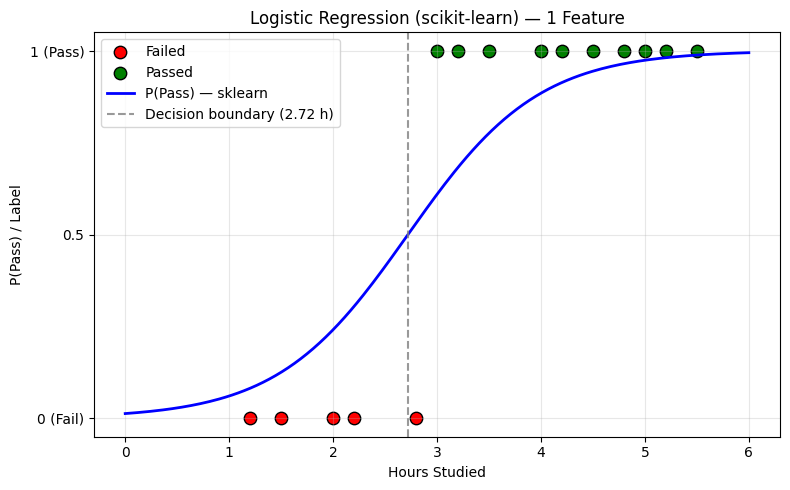

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Use ONLY hours studied for visualization
hours = X[:, 0].reshape(-1, 1)   # first column = hours_studied

# Train 1-feature model
model_1d = LogisticRegression()
model_1d.fit(hours, y)

# Create smooth curve
hours_curve = np.linspace(0, 6, 200).reshape(-1, 1)
p_curve = model_1d.predict_proba(hours_curve)[:, 1]

# Decision boundary: -b / w
boundary = -model_1d.intercept_[0] / model_1d.coef_[0][0]

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(hours[y == 0], y[y == 0],
            color='red', s=80, label='Failed', edgecolors='black')

plt.scatter(hours[y == 1], y[y == 1],
            color='green', s=80, label='Passed', edgecolors='black')

plt.plot(hours_curve, p_curve, 'b-', linewidth=2, label='P(Pass) — sklearn')

plt.axvline(boundary, color='gray', linestyle='--',
            alpha=0.8, label=f'Decision boundary ({boundary:.2f} h)')

plt.xlabel('Hours Studied')
plt.ylabel('P(Pass) / Label')
plt.title('Logistic Regression (scikit-learn) — 1 Feature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yticks([0, 0.5, 1], ['0 (Fail)', '0.5', '1 (Pass)'])
plt.tight_layout()
plt.show()

---
# Exercise 2 (30%): Same problem with scikit-learn

**Your turn.** Use the **same 15-student dataset** (hours_studied, hours_slept, attendance → pass/fail) from the NumPy exercise above, but this time implement logistic regression using **scikit-learn**. Replace each `# TODO` with your code.

### 1. Data: build X and y

Use the same 15 samples. For sklearn, **X** should be (15, 3) — one column per feature (no extra column of 1s; sklearn adds the intercept). **y** should be a 1D array of 0s and 1s.

In [37]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Same 15-student data as the NumPy exercise
hours_studied = np.array([1.2, 1.5, 2.0, 2.2, 2.8, 3.0, 3.2, 3.5, 4.0, 4.2, 4.5, 4.8, 5.0, 5.2, 5.5], dtype=np.float64)
hours_slept   = np.array([5.0, 6.0, 5.5, 6.5, 7.0, 6.0, 7.5, 7.0, 8.0, 7.0, 8.0, 7.5, 8.0, 6.5, 8.0], dtype=np.float64)
attendance    = np.array([0.6, 0.7, 0.5, 0.8, 0.6, 0.9, 0.7, 0.85, 0.9, 0.95, 0.8, 0.9, 1.0, 0.75, 0.95], dtype=np.float64)
passed        = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.int64)

# TODO: Build X with shape (15, 3) — columns: hours_studied, hours_slept, attendance (use np.column_stack)
X = np.column_stack((hours_studied, hours_slept, attendance))

# TODO: y is just passed (1D array of length 15). No need to reshape for sklearn.
y = passed

# print("X shape:", X.shape, "  y shape:", y.shape)

### 2. Fit model, predict, and accuracy

In [35]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Create and train model
model = LogisticRegression(fit_intercept=True, random_state=42)
model.fit(X, y.ravel())   # ravel() ensures y is 1D if needed

# Predict class labels
y_pred = model.predict(X)

# Predict probabilities for class 1 (Pass)
y_proba = model.predict_proba(X)[:, 1]

# Compute training accuracy
accuracy = (y_pred == y.ravel()).mean()

print("Training accuracy:", accuracy)

Training accuracy: 0.9333333333333333


### 3. Learned coefficients and predict for a new student


In [36]:

print("Intercept:", model.intercept_[0])
print("Coefficients (hours_studied, hours_slept, attendance):", model.coef_[0])

new_student = np.array([[3.8, 7, 0.88]])
pred = model.predict(new_student)
proba = model.predict_proba(new_student)[0, 1]
print(f"New student → P(pass) = {proba:.3f} → {'Pass' if pred[0] == 1 else 'Fail'}")

Intercept: -7.0193345650524455
Coefficients (hours_studied, hours_slept, attendance): [1.40681377 0.45640094 0.24651745]
New student → P(pass) = 0.850 → Pass
